In [1]:
import numpy as np

# Data handling
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn
import torch # Our new deep learning package!

# Data Loading
from torch.utils.data import Dataset, DataLoader

# Model building
import torch.nn as nn
import torch.nn.functional as F

# Training
import torch.optim as optim

Use the same random seed throughout this notebook.

In [2]:
random_seed = 42

# Load the training data.

Load the training data as before and add missing column labels.

In [3]:
df_digits = pd.read_csv('mnist_train.csv',header=None)
col_labels = ['label'] + [f'pixel_{i:03d}' for i in range(784)]
df_digits.columns = col_labels
df_digits.head()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Prepare data for training

In [4]:
# Separate features (pixel values) from labels; be sure they are arrays and not pandas Series
pixel_values = df_digits.drop('label',axis=1).values / 255 # Normalize between 0 and 1
labels = df_digits['label'].values

# Reshape so channel comes first (N_examples, 784) -> (N_examples, 1, 28, 28)
pixel_values = np.reshape(pixel_values, (-1, 1, 28, 28)).astype(np.float32)
labels = labels.astype(np.int64)

# Train / validation split
pixels_train, pixels_val, labels_train, labels_val = sklearn.model_selection.train_test_split(pixel_values, labels,
                                                                                             train_size=0.85,
                                                                                             stratify=labels,
                                                                                             random_state=random_seed)

### Create custom dataset class.

We need to create our own kind of object for handling the data.

This is because PyTorch's `DataLoader` expects input that has three methods:
* `__init__` -> Store the data as tensors (accessed as features of self)
* `__len__` -> How many samples?
* `__getitem__` -> return a single sample

By passing `Dataset` as the argument for the class, it "inherits" properties of the `Dataset` object we imported at the top of this script.

**QUESTION**
* Does OrganoidTracker do this?

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Use this class to make our datasets and so-called `DataLoaders`. The `DataLoader` can make shuffled batches of your dataset that you use throughout the training.

In [6]:
batch_size = 128
train_dataset = MNISTDataset(pixels_train, labels_train)
val_dataset = MNISTDataset(pixels_val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Create the CNN with custom class

Questions:
* Assuming inheritance from nn.Module is important?
* What is `super`?
* Need to understand every line of convolutional blocks, and how are these numbers decided?

In [7]:
class CNN(nn.Module):
    def __init__(self):
        # Define many methods for this object
        
        super(CNN, self).__init__()
        # Conv Block 1: 1→32 channels
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # 28x28 → 28x28
        self.pool1 = nn.MaxPool2d(2, 2)               # 28x28 → 14x14
        self.drop1 = nn.Dropout2d(0.25)
        
        # Conv Block 2: 32→64 channels  
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 14x14 → 14x14
        self.pool2 = nn.MaxPool2d(2, 2)               # 14x14 → 7x7
        self.drop2 = nn.Dropout2d(0.25)
        
        # Classifier
        self.fc1 = nn.Linear(64 * 7 * 7, 128)         # 3136 → 128
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)                 # 128 → 10 digits
    
    def forward(self, x):
        # apply the methods defined above in order to input data x
        
        # Block 1
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.drop1(x)
        
        # Block 2
        x = F.relu(self.conv2(x)) 
        x = self.pool2(x)
        x = self.drop2(x)
        
        # Classifier
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

In [8]:
# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

print(f"Using device: {device}")
print(model)

Using device: cuda
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Train the CNN

**QUESTION**:
* What is the Adam optimizer? What are its kwargs? (And why don't I see learning rate? or patience?)
* What is cross entropy Loss?
* For each epoch, we iterate over all the batches as defined in train_loader - but what happens in each batch?

On my Mac laptop CPU, it took about 1 min / epoch. Almost as fast the non-linear SVM for training!

In [9]:
# Our loss function
criterion = nn.CrossEntropyLoss()

# Our optimizer
# Parameters are a feature of the model object, instantiated before
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 10

# Keep track during each epoch of the training loss and validation accuracy
train_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    # Images and labels are part of `train_loader`, which we also instantiated above
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Loss={epoch_loss:.4f}, Val Acc={epoch_acc:.4f}')

Epoch 1/10: Loss=0.4343, Val Acc=0.9714
Epoch 2/10: Loss=0.1410, Val Acc=0.9806
Epoch 3/10: Loss=0.1097, Val Acc=0.9840
Epoch 4/10: Loss=0.0930, Val Acc=0.9854
Epoch 5/10: Loss=0.0802, Val Acc=0.9852
Epoch 6/10: Loss=0.0736, Val Acc=0.9868
Epoch 7/10: Loss=0.0666, Val Acc=0.9889
Epoch 8/10: Loss=0.0616, Val Acc=0.9876
Epoch 9/10: Loss=0.0568, Val Acc=0.9860
Epoch 10/10: Loss=0.0537, Val Acc=0.9880


Highest validation accuracy: 0.9889


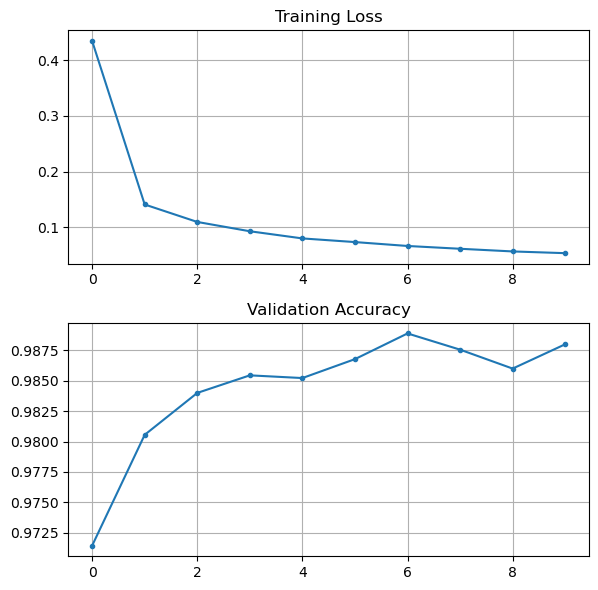

In [10]:
# Plot training curves
fig, axes = plt.subplots(2,1, figsize=(6,6))
axes[0].plot(train_losses,'.-')
axes[0].set_title('Training Loss')
axes[0].grid()

axes[1].plot(val_accuracies,'.-')
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
axes[1].grid()

print(f'Highest validation accuracy: {np.max(val_accuracies):.4f}')

As expected, the training loss decreases with every epoch, as that is explicitly what we use to update the weights. However, the validation accuracy does not always increase - some model updates do worse in the validation set (i.e., have signs of overfitting).

From curves like this, we can pick the epoch that produced the best results, i.e., highest validation accuracy. When I ran this model, I got 0.9889 validation accuracy, technically higher than the 0.9858 accuracy I got from my best SVM.

Then, to really report model accuracy, we can use our held-out test data.

# Future exploration

* Compare your SVM to your CNN. Which gave the most accurate model?
* What other factors might be importance when picking which model to use: Which trained faster? Which has fewer parameters? Which gives faster inference?
* Are the convolutions that were learned somehow interpretable?
* Augment the training data with `transforms.RandomRotation`
* Play with stopping criteria to see if you can automate model training without having to pick the number of epochs.

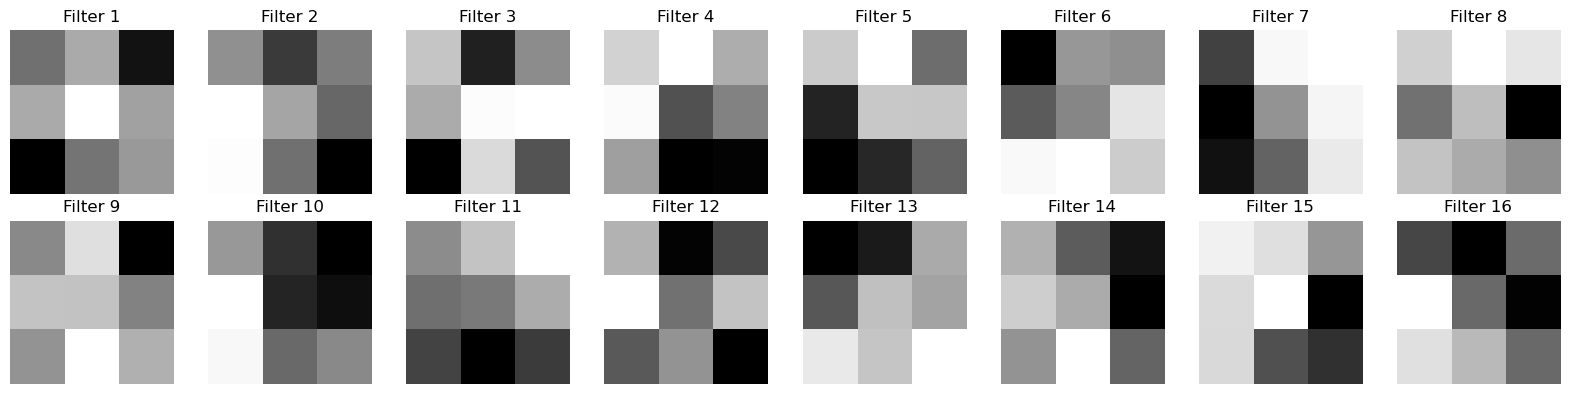

In [11]:
fig, axes = plt.subplots(2,8, figsize=(16,4))

with torch.no_grad():
    filters = model.conv1.weight.cpu().data.numpy()

    for i, ax in enumerate(axes.flat):
        ax.imshow(filters[i,0], cmap='gray')
        ax.set_title(f'Filter {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()